In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nrclex import NRCLex
from tqdm import tqdm
import re
import empath
import nltk

In [ ]:
df = pd.read_parquet('rest_tweets_15_19.parquet')

print(df.shape)
print(df.columns)


(2754531, 5)
Index(['business_id', 'user_id', 'stars', 'text', 'date'], dtype='object')


## cleaning

In [ ]:

tqdm.pandas()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['text'].progress_apply(clean_text)


100%|██████████| 2754531/2754531 [01:49<00:00, 25068.44it/s]


## downloading the punkt

In [ ]:
nltk.download('punkt')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger') 
nltk.download('wordnet')  
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Paarth\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Paarth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Paarth\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Paarth\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Paarth\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

## Extracting Empath lexicon

In [ ]:
lexicon = empath.Empath()


categories = ['positive', 'negative', 'joy', 'sadness', 'disgust', 'anger', 'trust', 'surprise', 'anticipation']

tqdm.pandas()

def extract_empath_features(text):
    return lexicon.analyze(text, categories=categories)
df['empath_features'] = df['clean_text'].progress_apply(extract_empath_features)


100%|██████████| 2754531/2754531 [07:00<00:00, 6543.80it/s]


## Merging the empath features

### Checking the mean values

In [ ]:
empath_df = df['empath_features'].apply(pd.Series)

empath_df = empath_df.add_prefix('empath_')

df = pd.concat([df, empath_df], axis=1)

df.drop(columns=['empath_features'], inplace=True)

## Extracting NRC emotion scores

In [ ]:
tqdm.pandas()
 
def extract_nrc_emotions(text):
    try:
        emotion = NRCLex(text)
        return emotion.raw_emotion_scores  
    except:
        return {}

df['nrc_emotions'] = df['clean_text'].progress_apply(extract_nrc_emotions)

100%|██████████| 2754531/2754531 [17:09<00:00, 2676.87it/s]


## Combining with main DataFrame


In [ ]:

nrc_df = df['nrc_emotions'].apply(pd.Series).fillna(0)

nrc_df = nrc_df.add_prefix('nrc_')

df = pd.concat([df, nrc_df], axis=1)
df.drop(columns=['nrc_emotions'], inplace=True)


## Check average emotion scores

nrc_positive        6.028962
nrc_anger           0.834621
nrc_disgust         0.697413
nrc_fear            0.877020
nrc_negative        1.987048
nrc_sadness         0.903427
nrc_joy             3.706973
nrc_trust           3.559639
nrc_anticipation    2.769450
nrc_surprise        1.348434
dtype: float64


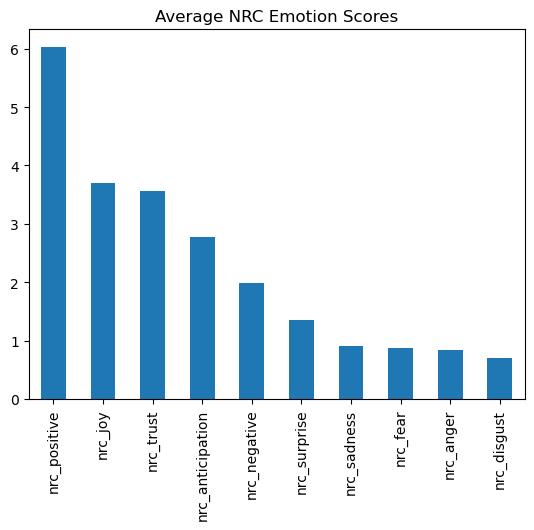

In [ ]:
print(df.filter(like='nrc_').mean())

df.filter(like='nrc_').mean().sort_values(ascending=False).plot(kind='bar', title='Average NRC Emotion Scores')
plt.show()


### Converting to parqute

In [ ]:
df.to_parquet("final_tweets_with_empath_and_nrc.parquet", index=False)

### Checking the distribution

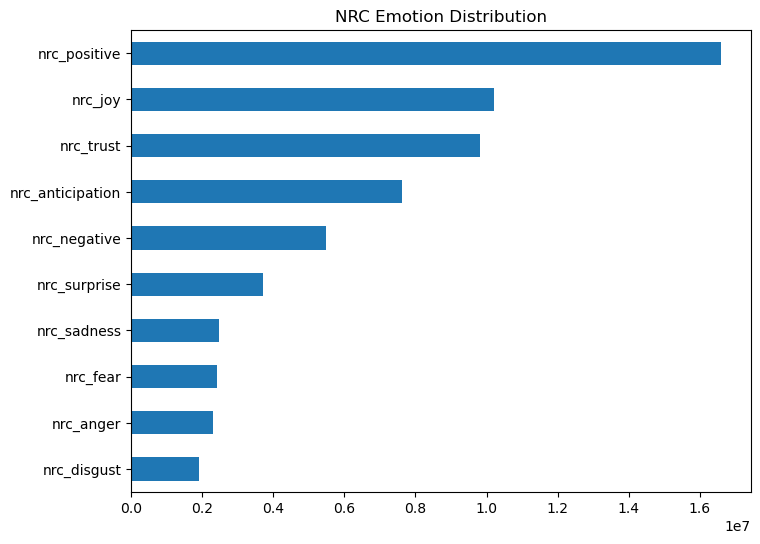

In [ ]:
nrc_cols = [col for col in df.columns if col.startswith('nrc_')]
df[nrc_cols].sum().sort_values().plot(kind='barh', figsize=(8, 6), title='NRC Emotion Distribution')
plt.show()
